In [108]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('products.csv')

## 01. Data Inspection


In [109]:
df.head(5)

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   object 
 2   category      2412 non-null   object 
 3   segment       2412 non-null   object 
 4   size          2412 non-null   object 
 5   color         2412 non-null   object 
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 150.9+ KB


In [111]:
df.describe()

,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000


In [112]:
df.shape

(2412, 8)

# 02. Data Types

In [113]:
for col_name in df.columns:
    print(f"Column '{col_name}':")
    display(df[col_name].apply(type).value_counts())
    print("\n" + "-" * 30 + "\n")

Column 'product_id':


,count
product_id,
<class 'int'>,2412



------------------------------

Column 'product_name':


,count
product_name,
<class 'str'>,2412



------------------------------

Column 'category':


...


------------------------------

Column 'price':


,count
price,
<class 'float'>,2412



------------------------------

Column 'cogs':


,count
cogs,
<class 'float'>,2412



------------------------------



# 03. Missing Values

In [114]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
segment,0
size,0
color,0
price,0
cogs,0


In [115]:
df.isna().sum()

,0
product_id,0
product_name,0
category,0
segment,0
size,0
color,0
price,0
cogs,0


In [116]:
df.isnull().sum().sum()

np.int64(0)

In [117]:
# Kiem tra cac dong co it nhat 1 o thieu
df[df.isnull().any(axis=1)]

,product_id,product_name,category,segment,size,color,price,cogs


In [118]:
# Kiem tra dong co tat ca gia tri deu thieu
df[df.isnull().all(axis=1)]


,product_id,product_name,category,segment,size,color,price,cogs


In [119]:
# Xoa gia tri thieu
## df = df.dropna()
# Dien gia tri thieu
## VD: df['Age'] = df['Age'].fillna(df['Age'].mean()), df['Age'] = df['Age'].fillna(df['Age'].median())
# Dien gia tri thieu voi phan loai:
## VD: df['Age'] = df['Age'].fillna(df['Age'].median())
# Dien bang gia tri co dinh, cu the:
## df['City'] = df['City'].fillna('Unknown')
# 9. Forward Fill / Backward Fill(hi dữ liệu có thứ tự, đặc biệt là dữ liệu thời gian)
## VD: df['Price'] = df['Price'].ffill(), df['Price'] = df['Price'].ffill()


# 04. Duplicates & Invalid Data

In [120]:
# Kiem tra gia tri trung lap va xem cac dong trung
df.duplicated().sum()
df[df.duplicated()]

,product_id,product_name,category,segment,size,color,price,cogs


In [121]:
# Kiem tra gia tri trung cua 1, nhieu cot
df.duplicated(subset=['category']).sum()
df['category'].value_counts()

,count
category,
Streetwear,1320
Outdoor,743
Casual,201
GenZ,148


In [122]:
# Xoa cac dong trung hoan toan, df = df.drop_duplicates()
# Xóa trùng theo một số cột, ex: df = df.drop_duplicates(subset=['Email'])
# Xoa trung giu ban ghi dau tien, ex: df = df.drop_duplicates(keep='first')

In [123]:
#Kiem tra du lieu khong hop le, co dieu kien
df[df['price'] <= 0].count()



,0
product_id,0
product_name,0
category,0
segment,0
size,0
color,0
price,0
cogs,0


In [124]:
# Kiểm tra category không hợp lệ
df.head(5)
df['category'].value_counts()

,count
category,
Streetwear,1320
Outdoor,743
Casual,201
GenZ,148


In [125]:
# Tim gia tri nam ngoai pham vi
# ex: df[~df['category'].isin([])]
# Xử lý dữ liệu không hợp lệ
# Xoa dong
# ex: df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]
# Chuyen thanh missing
# ex: df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = np.nan
# Thay the gia tri
# df['Gender'] = df['Gender'].replace({})
# Kiem tra khoang trang gia tri bat thuong
before = df['category'].nunique()
after = df['category'].str.strip().str.lower().nunique()

if before != after:
    print(f"Có vấn đề: {before} giá trị unique -> còn {after} sau khi chuẩn hóa")
else:
    print("Không phát hiện khoảng trắng/viết hoa thừa")

Không phát hiện khoảng trắng/viết hoa thừa


# 05. Outliers

In [126]:
# Nếu max lớn bất thường so với 75%, có thể cần kiểm tra Outlier. -> Phát hiện bất thường cần kiểm tra
df['price'].describe()

,price
count,2412.000000
mean,4928.216231
std,4776.737669
min,9.056594
25%,59.444924
50%,4399.605000
75%,7720.513784
max,40950.000000


In [127]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[
    (df['price'] < lower) |
    (df['price'] > upper)
]
print("So luong gia tri outlier: ", len(outliers))

print("Gia tri index cua cac dong: ", outliers.index)


So luong gia tri outlier:  31
Gia tri index cua cac dong:  Index([ 313,  427,  661,  674,  699,  712,  718,  760,  761,  762,  763,  768,
        777,  780,  785,  791,  792,  796,  806,  814,  818,  832,  839,  850,
        859,  860,  861,  863,  867,  934, 1451],
      dtype='int64')


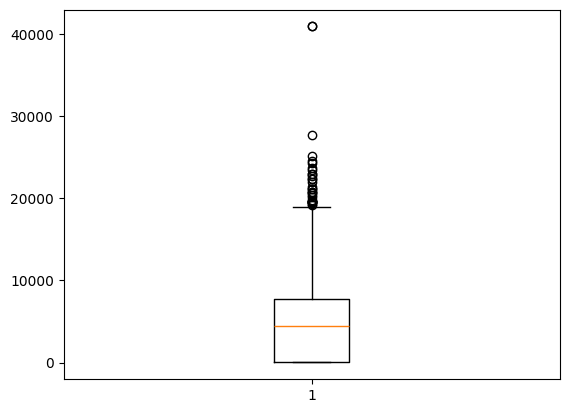

In [128]:
plt.boxplot(df['price'].dropna())
plt.show()

In [138]:
# thay Outlier bằng giới hạn trên/dưới.
df['price'] = df['price'].clip(lower, upper)

In [130]:
'''
Thay thế bằng median
median = df['price'].median()
df.loc[
    (df['Price'] < lower) | (df['Price'] > upper),
    'Price'
] = median
'''

"\nThay thế bằng median\nmedian = df['price'].median()\ndf.loc[\n    (df['Price'] < lower) | (df['Price'] > upper),\n    'Price'\n] = median\n"

In [139]:
#Kiem tra lai outlier
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[
    (df['cogs'] < lower) |
    (df['cogs'] > upper)
]
print("So luong gia tri outlier: ", len(outliers))

So luong gia tri outlier:  0


In [132]:
df['cogs'].describe() #tương tự

,cogs
count,2412.000000
mean,3868.346732
std,3878.584151
min,5.183829
25%,35.066367
50%,3184.934093
75%,5864.916462
max,38902.500000


In [133]:
Q1 = df['cogs'].quantile(0.25)
Q3 = df['cogs'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[
    (df['cogs'] < lower) |
    (df['cogs'] > upper)
]
print("So luong gia tri outlier: ", len(outliers))

print("Gia tri index cua cac dong: ", outliers.index)

# Thay doi gia tri outlier
df['cogs'] = df['cogs'].clip(lower, upper)

So luong gia tri outlier:  37
Gia tri index cua cac dong:  Index([   5,   65,   90,  182,  204,  215,  313,  552,  674,  699,  712,  718,
        753,  754,  760,  762,  763,  764,  766,  768,  777,  785,  791,  792,
        806,  814,  818,  839,  853,  854,  859,  861,  863,  926,  927, 1021,
       1451],
      dtype='int64')


In [134]:
# Thay doi gia tri outlier
df['cogs'] = df['cogs'].clip(lower, upper)

In [140]:
# df.to_csv('products_cleaned.csv', index=False)